# Companion Masterclass: Loss Surface Geometry & Optimization Dynamics

### An In-Depth Study of Hessian Curvature, Condition Numbers, and First- vs. Second-Order Solvers

**Audience:** ML engineers, researchers, and competitive data scientists  
**Topics:**
- Quadratic loss geometry & analytical Hessian $H = \frac{2}{N} X^T X$
- Condition number $\kappa = \lambda_{\max} / \lambda_{\min}$ and canyon stretching
- Comparative trajectories: SGD, Momentum, RMSprop, Adam, and Newton-Raphson
- Theoretical convergence bounds: $\eta < \frac{2}{\lambda_{\max}}$

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.visualization import (
    plot_loss_contours,
    compare_optimizer_trajectories,
    visualize_conditioning_impact
)
from src.solvers import NewtonLinearRegression

---
## 1. The Condition Number & Loss Canyon Curvature

For linear regression with MSE cost, the loss function is strictly quadratic:
$$J(w) = \frac{1}{N} (Xw - y)^T (Xw - y)$$
The Hessian matrix is constant everywhere:
$$H = \nabla^2 J(w) = \frac{2}{N} X^T X$$

The **Condition Number** $\kappa(H)$ measures the eccentricity of the quadratic bowl:
$$\kappa(H) = \frac{\lambda_{\max}(H)}{\lambda_{\min}(H)}$$
- $\kappa \approx 1$: Perfectly circular, isotropic loss contours. Gradient vectors point directly toward the global minimum.
- $\kappa \gg 1$: Highly stretched elliptical canyons. Gradient vectors point almost perpendicular to the optimal descent path, causing vanilla SGD to oscillate violently!

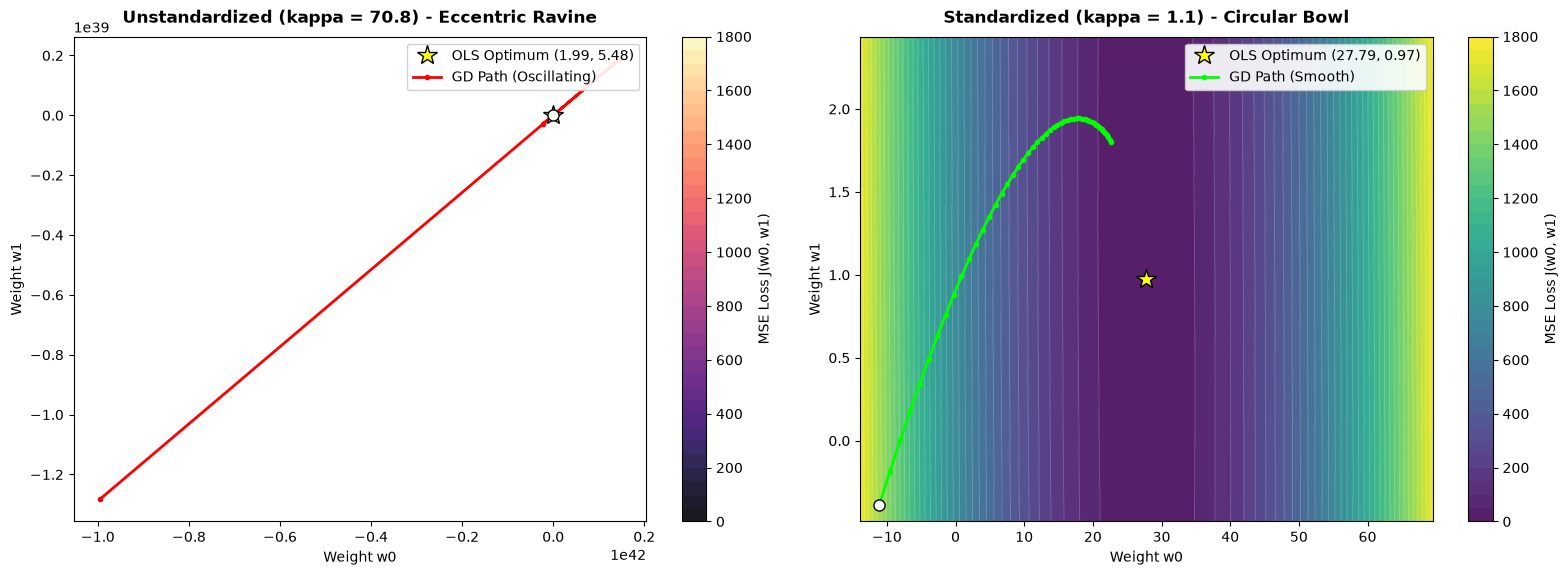

In [2]:
np.random.seed(42)
N = 200
X_raw = np.column_stack([np.random.normal(0, 15.0, N), np.random.normal(0, 0.2, N)])
y_raw = 2.0 * X_raw[:, 0] + 5.0 * X_raw[:, 1] + np.random.normal(0, 0.5, N)
fig, axes = visualize_conditioning_impact(X_raw, y_raw)
plt.show()

## 2. Multi-Optimizer Trajectory Showdown

We project the descent paths of **SGD, Momentum, RMSprop, Adam, and Newton-Raphson** on the exact same 2D loss surface.

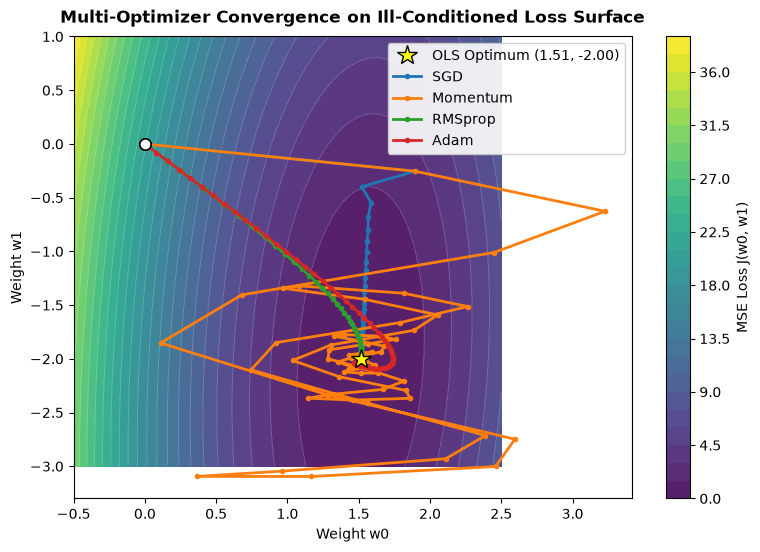

In [3]:
np.random.seed(42)
N = 100
# Generate moderately ill-conditioned 2D data (kappa ~ 15)
X_demo = np.column_stack([
    np.random.normal(0, 3.0, N),
    np.random.normal(0, 0.8, N)
])
y_demo = 1.5 * X_demo[:, 0] - 2.0 * X_demo[:, 1] + np.random.normal(0, 0.2, N)

trajectories = compare_optimizer_trajectories(
    X=X_demo,
    y=y_demo,
    optimizers=["sgd", "momentum", "rmsprop", "adam"],
    learning_rate=0.08,
    n_epochs=60,
)
fig, ax = plot_loss_contours(
    X_sub=X_demo,
    y=y_demo,
    w0_range=(-0.5, 2.5),
    w1_range=(-3.0, 1.0),
    trajectories=trajectories,
    title="Multi-Optimizer Convergence on Ill-Conditioned Loss Surface"
)
plt.show()

## 3. Second-Order Newton-Raphson: 1-Step Quadratic Exactness

Because MSE is quadratic, a single Newton step jumps directly to the global optimum:
$$\Delta w = - H^{-1} \nabla_w J = - \left( \frac{2}{N} X^T X \right)^{-1} \left( \frac{2}{N} X^T (Xw^{(0)} - y) \right) = (X^T X)^{-1} X^T y - w^{(0)}$$
$$w^{(1)} = w^{(0)} + \Delta w = (X^T X)^{-1} X^T y$$

In [4]:
newton = NewtonLinearRegression()
newton.fit(X_demo, y_demo)

print(f"Newton-Raphson converged in: {newton.n_iter_} step(s)!")
print(f"Final gradient norm: {newton.grad_norm_:.8f}")
print(f"Recovered Weights: {np.round(newton.weights, 4)}, Bias: {newton.bias:.4f}")

Newton-Raphson converged in: 2 step(s)!
Final gradient norm: 0.00000000
Recovered Weights: [ 1.5151 -2.0031], Bias: 0.0177
